<a href="https://colab.research.google.com/github/hasnainaliasghar/ai-journey/blob/main/08%20Pytorch/ANN/ArtificialNeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [75]:
import pandas as pd
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [76]:
#random seed for reporducibility
torch.manual_seed(42)

# Data Processing

In [77]:
df = pd.read_csv("fmnist_small.csv")
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,125,72,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,3,0,2,0,0,210,228,228,233,0,0,0,0,0,0,0,0,0,31,81,133,184,201,190,117,0,0,2,1,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,0,43,117,34,15,24,33,117,80,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,51,144,152,...,157,158,161,148,159,58,0,6,0,0,0,0,0,0,0,0,0,4,0,60,143,143,148,146,152,152,148,148,147,145,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,0,0,0,2,0,33,114,37,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,...,11,17,13,13,11,10,7,5,5,5,7,0,0,0,1,0,0,41,69,88,86,94,106,114,118,47,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,0,2,0,58,145,114,10,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,...,165,153,155,134,143,172,215,62,0,0,0,0,0,0,0,0,10,190,178,194,209,211,209,205,211,215,213,217,225,228,213,203,174,151,188,10,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,1,0,0,0,0,0,0,0,0,0,1,147,114,108,110,108,74,55,113,131,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,61,246,...,238,215,255,164,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,24,74,145,6,0,0,27,137,76,69,12,0,0,0,0,0,0,0,0
5996,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5997,8,0,0,0,0,0,0,0,0,0,0,0,23,125,109,104,107,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,2,0,68,...,139,157,186,252,255,154,53,238,0,0,0,0,0,0,11,61,0,0,36,91,67,93,126,133,135,139,135,143,132,79,39,47,2,0,0,29,0,0,0,0
5998,4,0,0,0,0,0,0,0,0,0,1,0,0,140,109,118,151,58,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,...,240,243,227,70,0,235,189,188,64,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,44,70,55,33,0,0,0,0,0,0,0,0,0,0,0


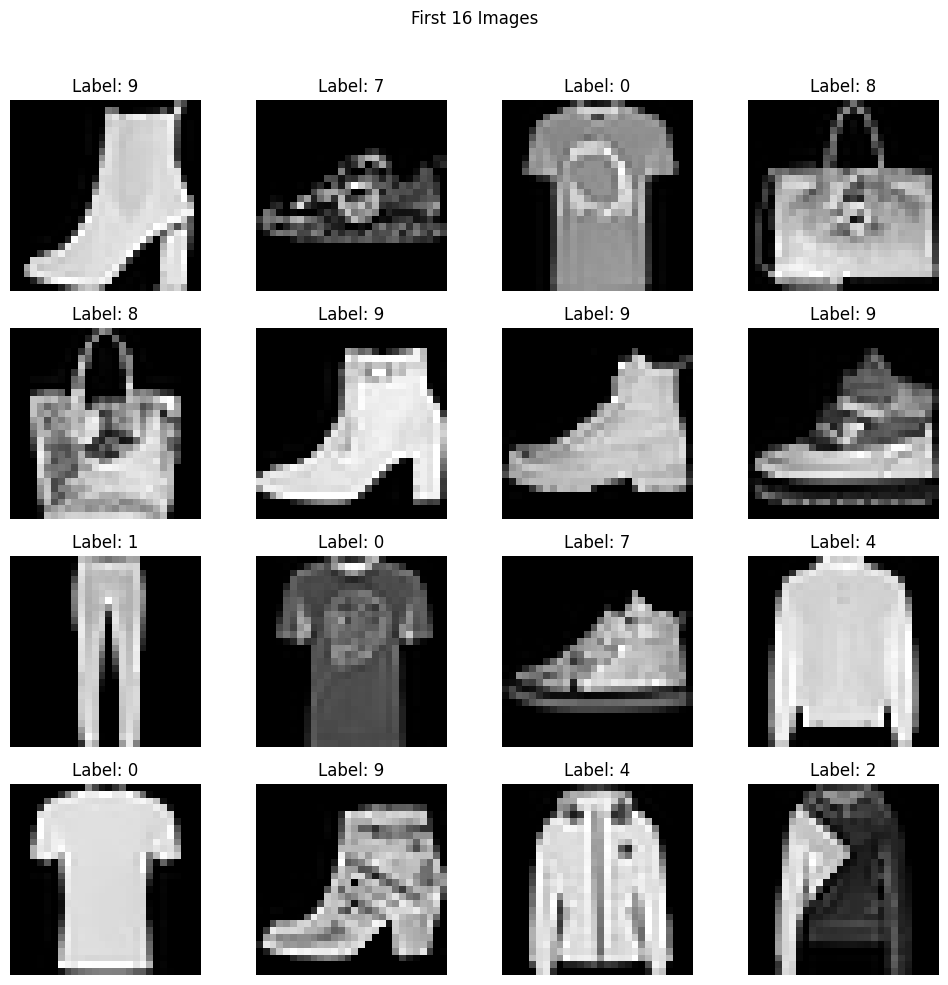

In [78]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images")

for i,ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img, cmap="gray")
  ax.axis("off")
  ax.set_title(f"Label: {df.iloc[i,0]}")

plt.tight_layout(rect = [0,0,1,0.96])
plt.show()

In [79]:
X = df.drop("label", axis=1).values
y = df["label"].values

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [81]:
X_train.shape

(4800, 784)

In [82]:
X_train = X_train/255.0
X_test = X_test/255.0

In [83]:
X_train

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.0627451, 0.       ,
        0.       ]])

In [84]:
#Custom DatasetClass
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features = torch.tensor(features, dtype = torch.float32)
    self.labels = torch.tensor(labels, dtype= torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,idx):
    return self.features[idx], self.labels[idx]

In [87]:
#create train dataset obj
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [88]:
#Create train test loader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [89]:
#define nn class
class MyNN(nn.Module):

  def __init__(self, num_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )

  def forward(self, x):
    return self.model(x)


In [90]:
#set of learning rate and epochs
epochs = 100
learning_rate = 0.1

In [91]:
model = MyNN(X_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [92]:
len(train_loader)

150

In [93]:
#training loop
for epoch in range(epochs):
  total_epoch_loss = 0
  for batch_features, batch_labels in train_loader:
    #forward pass
    outputs = model(batch_features)

    #calculate loss
    loss = criterion(outputs, batch_labels)
    optimizer.zero_grad()
    #back propagation
    loss.backward()

    #update grads
    optimizer.step()

    total_epoch_loss += loss.item()

  print(f"Epoch {epoch+1}, Loss: {total_epoch_loss/len(train_loader)}")

Epoch 1, Loss: 1.3216368440786999
Epoch 2, Loss: 0.7793365436792373
Epoch 3, Loss: 0.6427524652083715
Epoch 4, Loss: 0.5751657336950302
Epoch 5, Loss: 0.528180201848348
Epoch 6, Loss: 0.49528750121593473
Epoch 7, Loss: 0.4602432996034622
Epoch 8, Loss: 0.4359459094206492
Epoch 9, Loss: 0.41829214423894884
Epoch 10, Loss: 0.3984092291692893
Epoch 11, Loss: 0.3850264506538709
Epoch 12, Loss: 0.3722685620188713
Epoch 13, Loss: 0.3477362078428268
Epoch 14, Loss: 0.3467242218057315
Epoch 15, Loss: 0.3138812760512034
Epoch 16, Loss: 0.3126461291313171
Epoch 17, Loss: 0.29552092105150224
Epoch 18, Loss: 0.2857150869568189
Epoch 19, Loss: 0.27084775785605114
Epoch 20, Loss: 0.26237100958824155
Epoch 21, Loss: 0.25756089876095456
Epoch 22, Loss: 0.24232648963729542
Epoch 23, Loss: 0.23957946779827277
Epoch 24, Loss: 0.2261324493587017
Epoch 25, Loss: 0.2233684351791938
Epoch 26, Loss: 0.21165308925012746
Epoch 27, Loss: 0.21910773759086927
Epoch 28, Loss: 0.21103892110288144
Epoch 29, Loss: 0.1

In [94]:
#set Evaluation
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [95]:
total = 0
correct = 0

with torch.no_grad():
  for batch_features, batch_labels in test_loader:
    outputs = model(batch_features)
    _, predicted = torch.max(outputs.data, 1)
    total += batch_labels.size(0)
    correct += (predicted == batch_labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy: {accuracy}%")

Accuracy: 83.25%
